# Hate Speech Text Classification — TF‑IDF + Logistic Regression, Word2Vec (Skip‑gram/CBOW) + GRU

This notebook continues from the shared preprocessing and implements **three model/embedding versions**:

1. **TF‑IDF + Logistic Regression** *(Version A — chosen because TF‑IDF is not sequential)*  
2. **Word2Vec Skip‑gram + GRU**
3. **Word2Vec CBOW + GRU**

**Key principle:** the cleaned text and splits are identical across versions. Only the feature representation changes.

---

## Outputs
- A results table comparing:
  - Accuracy
  - Macro‑F1
  - Precision/Recall (macro)
  - Confusion matrix
- Optional: saved artifacts (vectorizer, word2vec models, GRU checkpoints)

> **Note:** This dataset is large (~440k rows). Training GRU end‑to‑end can take time on CPU.  
> The notebook includes parameters to (optionally) subsample for fast experimentation while keeping the pipeline correct.


In [34]:
# Cell 0 — Imports and configuration
import os
import re
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

from gensim.models import Word2Vec

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns


DEVICE: cpu


## Cell 0 — What this does
- Imports libraries for:
  - **TF‑IDF + Logistic Regression** (scikit‑learn)
  - **Word2Vec** training (gensim)
  - **GRU classifier** (PyTorch)
- Fixes randomness using `SEED=42` to make:
  - splits
  - Word2Vec initialization
  - PyTorch weight initialization  
  more reproducible across runs.
- Detects whether CUDA is available; if not, runs on CPU.


In [35]:
# Cell 1 — Load the shared preprocessed dataset (or create it if missing)

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


RAW_PATH = r"HateSpeechDataset.csv"
PREPROCESSED_PATH = r"HateSpeechDataset_preprocessed.csv"

# keep negations
KEEP_WORDS = {"no", "not", "nor", "never", "none", "n't"}

BASE_STOP = set(ENGLISH_STOP_WORDS) - KEEP_WORDS
WIKI_WEB_NOISE = {
    "wikipedia","wiki","page","pages","article","articles","edit","edited","source","revision",
    "retrieved","citation","citations","category","template","ref","thumb","file","image",
    "http","https","www","com","org","net","html","php","asp","htm","jpg","png",
    "deletion","thanks","time","new","use","make","sut","s","u"
}
GENERIC_NOISE = {"just","like","talk","want","know","think","good","people","does","did"}
MANUAL_REMOVE = BASE_STOP | WIKI_WEB_NOISE | GENERIC_NOISE

URL_RE = re.compile(r"\b(?:https?://|www\.)\S+\b", re.IGNORECASE)
EMAIL_RE = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", re.IGNORECASE)
USER_RE = re.compile(r"@[A-Za-z0-9_]+\b")
HTML_TAG_RE = re.compile(r"<[^>]+>")
WIKI_BRACKET_RE = re.compile(r"\[\[.*?\]\]|\{\{.*?\}\}|\[http[^\]]+\]", re.IGNORECASE)

def base_normalize(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = s.replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"')

    s = URL_RE.sub(" ", s)
    s = EMAIL_RE.sub(" ", s)
    s = USER_RE.sub(" ", s)
    s = HTML_TAG_RE.sub(" ", s)
    s = WIKI_BRACKET_RE.sub(" ", s)

    s = s.replace("&amp;", " and ").replace("&lt;", " ").replace("&gt;", " ").replace("&nbsp;", " ")
    s = re.sub(r"[^a-z0-9']+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()

    toks = [w for w in s.split() if len(w) > 1 and w not in MANUAL_REMOVE]
    return " ".join(toks)

def learn_auto_noise_from_train(train_text, y_train, top_k=120, min_df=3, max_df=0.95):
    v = TfidfVectorizer(
        ngram_range=(1,1),
        min_df=min_df,
        max_df=max_df,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b"
    )
    X = v.fit_transform(train_text)
    feats = np.array(v.get_feature_names_out())
    global_mean = np.asarray(X.mean(axis=0)).ravel()

    classes = np.unique(y_train)
    if len(classes) == 2:
        c0, c1 = classes[0], classes[1]
        m0 = np.asarray(X[np.where(y_train == c0)[0]].mean(axis=0)).ravel()
        m1 = np.asarray(X[np.where(y_train == c1)[0]].mean(axis=0)).ravel()
        ratio = (m0 + 1e-9) / (m1 + 1e-9)

        top_global = np.argsort(-global_mean)[:2000]
        near_equal = top_global[(ratio[top_global] >= 0.85) & (ratio[top_global] <= 1.15)]
        chosen = near_equal[np.argsort(-global_mean[near_equal])][:top_k]
    else:
        class_means = []
        for c in classes:
            class_means.append(np.asarray(X[np.where(y_train == c)[0]].mean(axis=0)).ravel())
        class_means = np.vstack(class_means)
        discr = class_means.std(axis=0) / (global_mean + 1e-9)
        top_global = np.argsort(-global_mean)[:2000]
        chosen = top_global[np.argsort(discr[top_global])][:top_k]

    auto_noise = set(feats[chosen]) - KEEP_WORDS
    return auto_noise

def remove_words(s: str, remove_set: set) -> str:
    return " ".join([w for w in s.split() if w not in remove_set])

def ensure_preprocessed(raw_path: str, preprocessed_path: str, seed: int = 42, rebuild: bool = True) -> pd.DataFrame:
    """Create shared preprocessed CSV with aggressive denoising."""
    if os.path.exists(preprocessed_path) and not rebuild:
        return pd.read_csv(preprocessed_path)

    df_raw = pd.read_csv(raw_path)
    df = df_raw.copy()

    # Remove duplicated header rows embedded as data
    mask_bad_header = df["Label"].astype(str).str.strip().str.lower().eq("label")
    df = df.loc[~mask_bad_header].reset_index(drop=True)

    # Labels
    df["Label"] = df["Label"].astype(str).str.strip()
    df["label"] = pd.to_numeric(df["Label"], errors="coerce")
    df = df[df["label"].isin([0, 1])].copy()
    df["label"] = df["label"].astype(int)

    # Base cleaning
    df["text"] = df["Content"].apply(base_normalize)
    df = df[df["text"].str.len() > 0].copy()

    # Split first (avoid leakage)
    train_val, test = train_test_split(df, test_size=0.10, random_state=seed, stratify=df["label"])
    val_size = 0.10 / 0.90
    train, val = train_test_split(train_val, test_size=val_size, random_state=seed, stratify=train_val["label"])

    train = train.copy(); val = val.copy(); test = test.copy()

    # Learn extra noise from TRAIN only
    auto_noise = learn_auto_noise_from_train(train["text"].values, train["label"].values, top_k=120)
    final_remove = (MANUAL_REMOVE | auto_noise) - KEEP_WORDS

    # Apply same removal to all splits
    train["text"] = train["text"].apply(lambda s: remove_words(s, final_remove))
    val["text"]   = val["text"].apply(lambda s: remove_words(s, final_remove))
    test["text"]  = test["text"].apply(lambda s: remove_words(s, final_remove))

    # Drop empties after aggressive cleaning
    train = train[train["text"].str.strip().ne("")]
    val   = val[val["text"].str.strip().ne("")]
    test  = test[test["text"].str.strip().ne("")]

    # Mark splits
    train["split"] = "train"
    val["split"] = "val"
    test["split"] = "test"

    df_out = pd.concat([train, val, test], axis=0, ignore_index=True)
    df_out.to_csv(preprocessed_path, index=False)

    print(f"[Saved] {preprocessed_path} | shape={df_out.shape} | auto_noise={len(auto_noise)}")
    return df_out

# Force rebuild once so new cleaning is used
df_all = ensure_preprocessed(RAW_PATH, PREPROCESSED_PATH, seed=SEED, rebuild=True)
print(df_all.head(3))
print(df_all["split"].value_counts())


[Saved] HateSpeechDataset_preprocessed.csv | shape=(439261, 6) | auto_noise=119
                                             Content Label  \
0  if you are not attractive bitch you am not mak...     0   
1  the afd section on your user page i suggest th...     0   
2  beijing taipei expressway does anyone find thi...     0   

                                         Content_int  label  \
0  [146715, 204, 26, 154, 76, 1265, 172, 26, 81, ...      0   
1  [146715, 3, 28716, 1956, 9, 72, 4236, 1830, 80...      0   
2  [146715, 10946, 57057, 45946, 124, 1980, 328, ...      0   

                                                text  split  
0        not attractive bitch not making drinks fuck  train  
1  afd section user suggest rephrase bit read ass...  train  
2  beijing taipei expressway proposal worthy atte...  train  
split
train    351395
val       43945
test      43921
Name: count, dtype: int64


## Cell 1 — What this does
- Loads `HateSpeechDataset_preprocessed.csv` if it already exists (recommended for speed and consistency).
- If not found, it **recreates the same shared preprocessing**:
  - removes duplicated header rows
  - cleans labels into `label ∈ {0,1}`
  - cleans `text`
  - creates stratified 80/10/10 split stored in `split`
- Returns a standardized dataframe `df_all` with columns: `id`, `text`, `label`, `split`.


In [36]:
# Cell 2 — Create train/val/test views

train_df = df_all[df_all["split"] == "train"].reset_index(drop=True)
val_df   = df_all[df_all["split"] == "val"].reset_index(drop=True)
test_df  = df_all[df_all["split"] == "test"].reset_index(drop=True)

print("Train:", train_df.shape, " Val:", val_df.shape, " Test:", test_df.shape)
print("Positive rate (train/val/test):",
      train_df["label"].mean(), val_df["label"].mean(), test_df["label"].mean())


Train: (351395, 6)  Val: (43945, 6)  Test: (43921, 6)
Positive rate (train/val/test): 0.18026722064912706 0.18017977016725453 0.18014161790487465


## Cell 2 — What this does
- Creates three separate DataFrames (`train_df`, `val_df`, `test_df`) based on the fixed `split` column.
- Prints sizes and label rates to verify stratification worked as intended.


In [37]:
# Cell 3 — Evaluation helpers (common to all models)

def eval_binary(y_true, y_pred, prefix=""):
    metrics = {
        f"{prefix}accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}macro_f1": f1_score(y_true, y_pred, average="macro"),
        f"{prefix}macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    return metrics

def print_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    print(title)
    print(cm)
    return cm


## Cell 3 — What this does
- Defines evaluation helpers used for TF‑IDF/LR and both GRU variants.
- Uses **macro‑averaged** precision/recall/F1 to handle class imbalance fairly (positive class is a minority).
- Prints a confusion matrix for interpretability.


# Version A — TF‑IDF + Logistic Regression

Why Logistic Regression (not GRU) for TF‑IDF?
- **TF‑IDF is a bag‑of‑words feature** (sparse vector) that **does not preserve token order**.
- A GRU is designed for ordered sequences, so the architecture is mismatched.
- Logistic Regression is a standard, strong baseline for TF‑IDF text classification.


In [38]:
# Cell 4 — Train TF‑IDF + Logistic Regression (tune C on validation)

# 1) Fit TF‑IDF on TRAIN ONLY (avoids leakage)
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    max_features=50000,
    sublinear_tf=True,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b"
)

X_train = vectorizer.fit_transform(train_df["text"])
X_val   = vectorizer.transform(val_df["text"])
X_test  = vectorizer.transform(test_df["text"])

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

# 2) Hyperparameter tuning (simple grid)
C_grid = [0.1, 0.3, 1.0, 3.0, 10.0]
best = {"C": None, "val_macro_f1": -1, "model": None}

for C in C_grid:
    clf = LogisticRegression(
        C=C,
        max_iter=2000,
        class_weight="balanced",   # helps with imbalance
        n_jobs=-1
    )
    clf.fit(X_train, y_train)
    val_pred = clf.predict(X_val)
    val_f1 = f1_score(y_val, val_pred, average="macro")
    print(f"C={C:<4}  val_macro_f1={val_f1:.4f}")

    if val_f1 > best["val_macro_f1"]:
        best.update({"C": C, "val_macro_f1": val_f1, "model": clf})

print("\nBest C:", best["C"], " Best val_macro_f1:", best["val_macro_f1"])

# 3) Evaluate on TEST
tfidf_lr_test_pred = best["model"].predict(X_test)

tfidf_lr_metrics = eval_binary(y_test, tfidf_lr_test_pred, prefix="tfidf_lr_")
print(tfidf_lr_metrics)
print_confusion(y_test, tfidf_lr_test_pred, title="TF‑IDF + LR — Confusion Matrix")


C=0.1   val_macro_f1=0.7567
C=0.3   val_macro_f1=0.7631
C=1.0   val_macro_f1=0.7654
C=3.0   val_macro_f1=0.7651
C=10.0  val_macro_f1=0.7628

Best C: 1.0  Best val_macro_f1: 0.7653817942252334
{'tfidf_lr_accuracy': 0.8375947724323217, 'tfidf_lr_macro_f1': 0.7682608867857263, 'tfidf_lr_macro_precision': 0.7422953201981769, 'tfidf_lr_macro_recall': 0.8255114312366747}
TF‑IDF + LR — Confusion Matrix
[[30406  5603]
 [ 1530  6382]]


array([[30406,  5603],
       [ 1530,  6382]])

## Cell 4 — What this does
- Builds a TF‑IDF vectorizer (1–2 grams) and **fits it only on training text** to prevent leakage.
- Trains Logistic Regression with `class_weight="balanced"` to reduce bias toward the majority class.
- Tunes the regularization strength `C` using **validation macro‑F1**.
- Evaluates the best model on the test set and prints metrics + confusion matrix.


# Word2Vec + GRU versions (Skip‑gram and CBOW)

For both Skip‑gram and CBOW, we:
1. Tokenize the cleaned text (simple whitespace split)
2. Train a Word2Vec model **using training tokens only**
3. Build an embedding matrix for PyTorch
4. Train a GRU classifier using padded token sequences


In [39]:
# Cell 5 — Tokenize text (shared for both Word2Vec variants)

def tokenize(text: str):
    # Because preprocessing already removed most punctuation and normalized spaces,
    # tokenization can be a simple split.
    return text.split()

train_tokens = [tokenize(t) for t in train_df["text"].tolist()]
val_tokens   = [tokenize(t) for t in val_df["text"].tolist()]
test_tokens  = [tokenize(t) for t in test_df["text"].tolist()]

# Pick a reasonable max length from training distribution (e.g., 95th percentile)
train_lens = np.array([len(x) for x in train_tokens], dtype=int)
MAX_LEN = int(np.quantile(train_lens, 0.95))
MAX_LEN = max(16, min(MAX_LEN, 256))  # keep within a sensible range
print("MAX_LEN (95th percentile, clipped):", MAX_LEN)


MAX_LEN (95th percentile, clipped): 60


## Cell 5 — What this does
- Tokenizes `text` using whitespace splitting.
  - This works because earlier preprocessing already normalized text and spacing.
- Computes training sequence lengths and sets `MAX_LEN` to the 95th percentile (then clips it).
  - This limits padding/truncation cost while keeping most sequences intact.


In [40]:
# Cell 6 — PyTorch dataset utilities for padded sequences

PAD_IDX = 0
UNK_IDX = 1

def build_vocab_from_w2v(w2v_model: Word2Vec):
    # Reserve 0:PAD, 1:UNK
    words = list(w2v_model.wv.index_to_key)
    stoi = {w: i+2 for i, w in enumerate(words)}
    itos = {i+2: w for i, w in enumerate(words)}
    itos[PAD_IDX] = "<PAD>"
    itos[UNK_IDX] = "<UNK>"
    return stoi, itos

def encode(tokens, stoi):
    return [stoi.get(tok, UNK_IDX) for tok in tokens]

def pad_trunc(ids, max_len: int):
    if len(ids) >= max_len:
        return ids[:max_len]
    return ids + [PAD_IDX] * (max_len - len(ids))

class TextSeqDataset(Dataset):
    def __init__(self, tokens_list, labels, stoi, max_len: int):
        self.tokens_list = tokens_list
        self.labels = labels.astype(np.float32)
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.tokens_list)

    def __getitem__(self, idx):
        tok = self.tokens_list[idx]
        ids = encode(tok, self.stoi)
        ids = pad_trunc(ids, self.max_len)
        x = torch.tensor(ids, dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y


## Cell 6 — What this does
- Defines a consistent integer encoding for tokens:
  - `0 = <PAD>` for padding
  - `1 = <UNK>` for out‑of‑vocabulary tokens
- Converts each document (list of tokens) → list of integer IDs using the Word2Vec vocabulary.
- Pads or truncates to `MAX_LEN` so batches have uniform shape.
- Implements a PyTorch `Dataset` that returns `(x, y)` pairs:
  - `x`: LongTensor of token IDs `[MAX_LEN]`
  - `y`: FloatTensor label (0.0 or 1.0)


In [41]:
# Cell 7 — Define a GRU classifier (PyTorch)

class GRUClassifier(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int, hidden_dim: int, n_layers: int,
                 dropout: float, pad_idx: int, pretrained_embeddings: np.ndarray | None = None,
                 freeze_embeddings: bool = False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)

        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.tensor(pretrained_embeddings, dtype=torch.float32))
        self.embedding.weight.requires_grad = not freeze_embeddings

        self.gru = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
            bidirectional=False
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: [B, T]
        emb = self.embedding(x)          # [B, T, D]
        out, h = self.gru(emb)           # h: [n_layers, B, H]
        last = h[-1]                     # [B, H] (last layer)
        logits = self.fc(self.dropout(last)).squeeze(1)  # [B]
        return logits

def macro_f1_from_logits(logits, y_true):
    probs = torch.sigmoid(logits).detach().cpu().numpy()
    y_pred = (probs >= 0.5).astype(int)
    y_true = y_true.detach().cpu().numpy().astype(int)
    return f1_score(y_true, y_pred, average="macro")

def train_gru_model(model, train_loader, val_loader, pos_weight, lr=1e-3, epochs=5, patience=2):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))

    best_state = None
    best_val_f1 = -1
    bad_epochs = 0

    for epoch in range(1, epochs+1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # Validation
        model.eval()
        val_logits_all = []
        val_y_all = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                logits = model(xb)
                val_logits_all.append(logits)
                val_y_all.append(yb)

        val_logits = torch.cat(val_logits_all, dim=0)
        val_y = torch.cat(val_y_all, dim=0)
        val_f1 = macro_f1_from_logits(val_logits, val_y)

        print(f"Epoch {epoch:02d} | train_loss={np.mean(train_losses):.4f} | val_macro_f1={val_f1:.4f}")

        # Early stopping
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


## Cell 7 — What this does
- Defines a **GRUClassifier**:
  - Embedding layer (initialized with Word2Vec vectors)
  - GRU encoder
  - Linear layer for binary classification (logit output)
- Uses `BCEWithLogitsLoss` (numerically stable for sigmoid + binary cross-entropy).
- Applies **`pos_weight`** in the loss to counter class imbalance.
- Implements a small training loop with:
  - validation macro‑F1 tracking
  - early stopping (`patience`)


In [42]:
# Cell 8 — Train Word2Vec and run GRU (helper function)

def train_word2vec(tokens_corpus, sg: int, vector_size=100, window=5, min_count=2, workers=4, epochs=5):
    # sg=1 -> Skip-gram, sg=0 -> CBOW
    w2v = Word2Vec(
        sentences=tokens_corpus,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=sg,
        workers=workers,
        seed=SEED
    )
    w2v.train(tokens_corpus, total_examples=len(tokens_corpus), epochs=epochs)
    return w2v

def build_embedding_matrix(w2v_model: Word2Vec, stoi: dict, emb_dim: int):
    vocab_size = max(stoi.values()) + 1  # because stoi starts at index 2
    mat = np.zeros((vocab_size, emb_dim), dtype=np.float32)

    # Initialize UNK with small random values (optional)
    rng = np.random.default_rng(SEED)
    mat[UNK_IDX] = rng.normal(0, 0.1, size=(emb_dim,)).astype(np.float32)

    for word, idx in stoi.items():
        if idx < 2:
            continue
        mat[idx] = w2v_model.wv[word]
    return mat

def run_w2v_gru_experiment(name: str, sg: int):
    print(f"\n==== {name} (sg={sg}) ====")

    # Optional speed knob: subsample training corpus for Word2Vec
    # Set to None to use full training data.
    SAMPLE_FOR_W2V = None  # e.g. 200_000
    tokens_for_w2v = train_tokens
    if SAMPLE_FOR_W2V is not None and SAMPLE_FOR_W2V < len(train_tokens):
        idx = np.random.default_rng(SEED).choice(len(train_tokens), size=SAMPLE_FOR_W2V, replace=False)
        tokens_for_w2v = [train_tokens[i] for i in idx]
        print("Word2Vec training corpus sampled to:", len(tokens_for_w2v))

    # 1) Train Word2Vec on TRAIN tokens only
    w2v = train_word2vec(tokens_for_w2v, sg=sg, vector_size=100, window=5, min_count=2, workers=4, epochs=5)

    # 2) Build vocab + embedding matrix
    stoi, itos = build_vocab_from_w2v(w2v)
    emb_dim = w2v.vector_size
    emb_matrix = build_embedding_matrix(w2v, stoi, emb_dim)

    # 3) Build datasets/loaders
    y_train = train_df["label"].values
    y_val   = val_df["label"].values
    y_test  = test_df["label"].values

    train_ds = TextSeqDataset(train_tokens, y_train, stoi, max_len=MAX_LEN)
    val_ds   = TextSeqDataset(val_tokens,   y_val,   stoi, max_len=MAX_LEN)
    test_ds  = TextSeqDataset(test_tokens,  y_test,  stoi, max_len=MAX_LEN)

    BATCH_SIZE = 256
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # 4) pos_weight for imbalance: (#neg / #pos)
    pos = y_train.sum()
    neg = len(y_train) - pos
    pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32)
    print("pos_weight:", pos_weight.item())

    # 5) Model + train
    model = GRUClassifier(
        vocab_size=emb_matrix.shape[0],
        emb_dim=emb_dim,
        hidden_dim=128,
        n_layers=1,
        dropout=0.3,
        pad_idx=PAD_IDX,
        pretrained_embeddings=emb_matrix,
        freeze_embeddings=False
    )

    model = train_gru_model(
        model,
        train_loader,
        val_loader,
        pos_weight=pos_weight,
        lr=1e-3,
        epochs=8,
        patience=2
    )

    # 6) Test evaluation
    model.eval()
    all_logits = []
    all_y = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb).detach().cpu()
            all_logits.append(logits)
            all_y.append(yb)

    logits = torch.cat(all_logits, dim=0).numpy()
    y_true = torch.cat(all_y, dim=0).numpy().astype(int)
    y_pred = (1 / (1 + np.exp(-logits)) >= 0.5).astype(int)

    metrics = eval_binary(y_true, y_pred, prefix=f"{name}_")
    print(metrics)
    print_confusion(y_true, y_pred, title=f"{name} — Confusion Matrix")

    return metrics


## Cell 8 — What this does
- Wraps the full Word2Vec→GRU pipeline into one reusable function:
  - Train Word2Vec on **training tokens only**
  - Build token→id vocabulary from Word2Vec learned vocabulary
  - Initialize a PyTorch embedding matrix with Word2Vec vectors
  - Train GRU with early stopping on validation macro‑F1
  - Evaluate on test with accuracy/macro‑F1 + confusion matrix
- Includes an optional `SAMPLE_FOR_W2V` parameter you can set if you need faster prototyping.


In [43]:
# Cell 9 — Run Word2Vec Skip‑gram + GRU
w2v_sg_metrics = run_w2v_gru_experiment(name="w2v_skipgram_gru", sg=1)


==== w2v_skipgram_gru (sg=1) ====


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

pos_weight: 4.547320365905762
Epoch 01 | train_loss=0.6886 | val_macro_f1=0.7686
Epoch 02 | train_loss=0.5462 | val_macro_f1=0.7832
Epoch 03 | train_loss=0.4690 | val_macro_f1=0.7855
Epoch 04 | train_loss=0.3984 | val_macro_f1=0.7758
Epoch 05 | train_loss=0.3384 | val_macro_f1=0.7739
Early stopping triggered.
{'w2v_skipgram_gru_accuracy': 0.8558775984153366, 'w2v_skipgram_gru_macro_f1': 0.7864674474987208, 'w2v_skipgram_gru_macro_precision': 0.7612210394451899, 'w2v_skipgram_gru_macro_recall': 0.8313852805055112}
w2v_skipgram_gru — Confusion Matrix
[[31316  4693]
 [ 1637  6275]]


## Cell 9 — What this does
- Runs the **Skip‑gram** Word2Vec training (`sg=1`) and then trains/evaluates the GRU classifier.


In [44]:
# Cell 10 — Run Word2Vec CBOW + GRU
w2v_cbow_metrics = run_w2v_gru_experiment(name="w2v_cbow_gru", sg=0)


==== w2v_cbow_gru (sg=0) ====


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


pos_weight: 4.547320365905762
Epoch 01 | train_loss=0.6793 | val_macro_f1=0.7583
Epoch 02 | train_loss=0.5529 | val_macro_f1=0.7737
Epoch 03 | train_loss=0.4739 | val_macro_f1=0.7654
Epoch 04 | train_loss=0.4049 | val_macro_f1=0.7684
Early stopping triggered.
{'w2v_cbow_gru_accuracy': 0.8403269506614148, 'w2v_cbow_gru_macro_f1': 0.7761122662910811, 'w2v_cbow_gru_macro_precision': 0.7486088860021471, 'w2v_cbow_gru_macro_recall': 0.8425130070841462}
w2v_cbow_gru — Confusion Matrix
[[30215  5794]
 [ 1219  6693]]


## Cell 10 — What this does
- Runs the **CBOW** Word2Vec training (`sg=0`) and then trains/evaluates the GRU classifier.


In [45]:
# Cell 11 — Combine results into a single comparison table

# w2v_*_metrics are returned when you run the GRU experiments.
# If you haven't run them yet, you can still build the table after execution.

rows = []
rows.append({"model": "TF‑IDF + Logistic Regression", **tfidf_lr_metrics})

if "w2v_sg_metrics" in globals():
    rows.append({"model": "Word2Vec Skip‑gram + GRU", **w2v_sg_metrics})
if "w2v_cbow_metrics" in globals():
    rows.append({"model": "Word2Vec CBOW + GRU", **w2v_cbow_metrics})

results_df = pd.DataFrame(rows)

# Keep a consistent set of columns
cols = ["model",
        "tfidf_lr_accuracy","tfidf_lr_macro_f1","tfidf_lr_macro_precision","tfidf_lr_macro_recall",
        "w2v_skipgram_gru_accuracy","w2v_skipgram_gru_macro_f1","w2v_skipgram_gru_macro_precision","w2v_skipgram_gru_macro_recall",
        "w2v_cbow_gru_accuracy","w2v_cbow_gru_macro_f1","w2v_cbow_gru_macro_precision","w2v_cbow_gru_macro_recall"]

# Some columns won't exist depending on execution order; show what exists.
available_cols = ["model"] + [c for c in cols if c in results_df.columns and c != "model"]
results_df = results_df[available_cols]

results_df


,model,tfidf_lr_accuracy,tfidf_lr_macro_f1,tfidf_lr_macro_precision,tfidf_lr_macro_recall,w2v_skipgram_gru_accuracy,w2v_skipgram_gru_macro_f1,w2v_skipgram_gru_macro_precision,w2v_skipgram_gru_macro_recall,w2v_cbow_gru_accuracy,w2v_cbow_gru_macro_f1,w2v_cbow_gru_macro_precision,w2v_cbow_gru_macro_recall
0,TF‑IDF + Logistic Regression,0.837595,0.768261,0.742295,0.825511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Word2Vec Skip‑gram + GRU,NaN,NaN,NaN,NaN,0.855878,0.786467,0.761221,0.831385,NaN,NaN,NaN,NaN
2,Word2Vec CBOW + GRU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.840327,0.776112,0.748609,0.842513


## Cell 11 — What this does
- Merges metrics from all three versions into one table for easy comparison in your report.
- Uses whatever metrics are available in the notebook session (so you can run in parts).


# Rubric upgrades (to hit “Exemplary”)

This section adds:
- **4+ EDA visualizations** (class balance, text length distribution, vocabulary frequency, TF-IDF feature inspection)
- **Embedding-specific preprocessing/adaptation notes**
- **Experiment tables** (hyperparams + metrics) to paste into the final report
- **Reproducibility hooks** (timing + random seeds already set)

All additions keep the **same shared preprocessing** and **same split**.


In [46]:
# Cell R1 — EDA setup (plots)
import matplotlib.pyplot as plt
from collections import Counter


## Cell R1 — What this does
- Imports **matplotlib** for the required visualizations.
- Imports `Counter` to compute simple vocabulary frequency statistics.


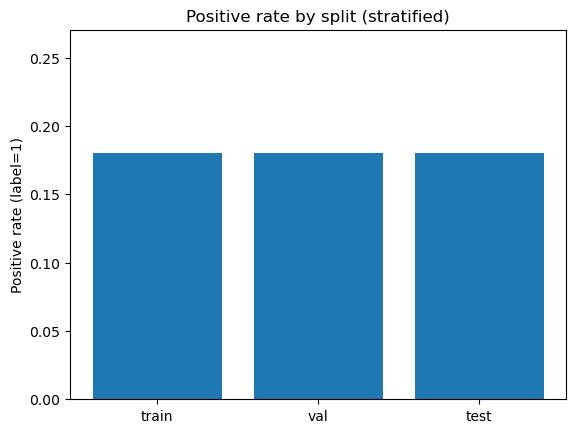

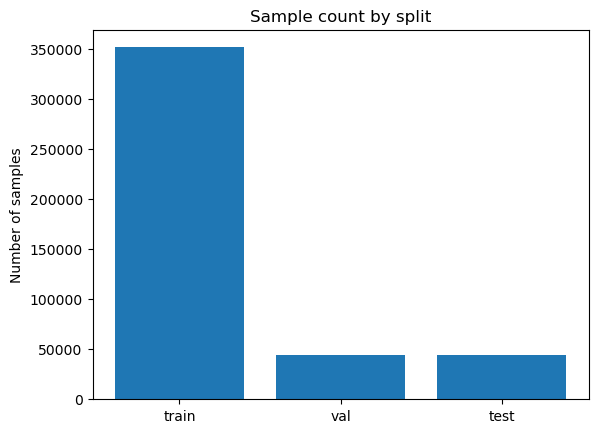

In [47]:
# Cell R2 — Plot 1: Class balance (train/val/test)
splits = ["train", "val", "test"]
pos_rates = [train_df["label"].mean(), val_df["label"].mean(), test_df["label"].mean()]
sizes = [len(train_df), len(val_df), len(test_df)]

plt.figure()
plt.bar(splits, pos_rates)
plt.title("Positive rate by split (stratified)")
plt.ylabel("Positive rate (label=1)")
plt.ylim(0, max(pos_rates)*1.5)
plt.show()

plt.figure()
plt.bar(splits, sizes)
plt.title("Sample count by split")
plt.ylabel("Number of samples")
plt.show()


## Cell R2 — What this does
- **Visualization 1:** positive label rate across train/val/test to demonstrate stratified splitting.
- **Visualization 2:** sample counts per split for transparency and reproducibility.


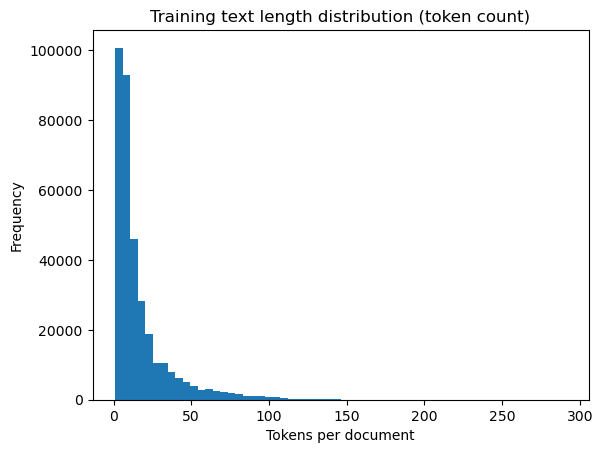

Token length quantiles (train):
{'p50': 9, 'p90': 40, 'p95': 60, 'p99': 99}


In [48]:
# Cell R3 — Plot 3: Text length distribution (tokens) on training data
train_tokens_lens = np.array([len(t.split()) for t in train_df["text"]], dtype=int)

plt.figure()
plt.hist(train_tokens_lens, bins=60)
plt.title("Training text length distribution (token count)")
plt.xlabel("Tokens per document")
plt.ylabel("Frequency")
plt.show()

# Quantiles for reporting / model design justification
quantiles = np.quantile(train_tokens_lens, [0.5, 0.9, 0.95, 0.99])
print("Token length quantiles (train):")
print({"p50": int(quantiles[0]), "p90": int(quantiles[1]), "p95": int(quantiles[2]), "p99": int(quantiles[3])})


## Cell R3 — What this does
- **Visualization 3:** histogram of token lengths in the training split.
- Reports length quantiles (p50/p90/p95/p99) to **justify `MAX_LEN`** for GRU padding/truncation in the methodology section.


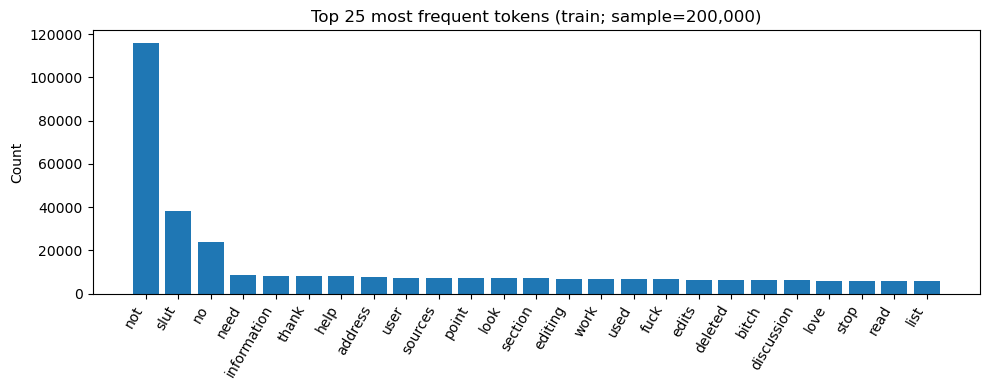

Top tokens: [('not', 115944), ('slut', 37997), ('no', 23701), ('need', 8766), ('information', 8062), ('thank', 8006), ('help', 7990), ('address', 7923), ('user', 7438), ('sources', 7407)]


In [49]:
# Cell R4 — Plot 4: Top vocabulary terms (frequency) on training data
# NOTE: This is word frequency on cleaned text, not TF-IDF weighting.

sample_size = 200_000  # for speed; increase or set None to use full training split
texts = train_df["text"]
if sample_size is not None and sample_size < len(texts):
    texts = texts.sample(sample_size, random_state=SEED)

counter = Counter()
for t in texts:
    counter.update(t.split())

top_k = 25
top_items = counter.most_common(top_k)
words = [w for w, c in top_items]
counts = [c for w, c in top_items]

plt.figure(figsize=(10, 4))
plt.bar(words, counts)
plt.title(f"Top {top_k} most frequent tokens (train; sample={len(texts):,})")
plt.ylabel("Count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

print("Top tokens:", top_items[:10])


## Cell R4 — What this does
- **Visualization 4:** top token frequencies in the training data (after shared cleaning).
- Helps you discuss dataset characteristics (common vocabulary, noise tokens like `<URL>`/`<USER>`).
- Uses optional sampling to keep runtime reasonable on large datasets.


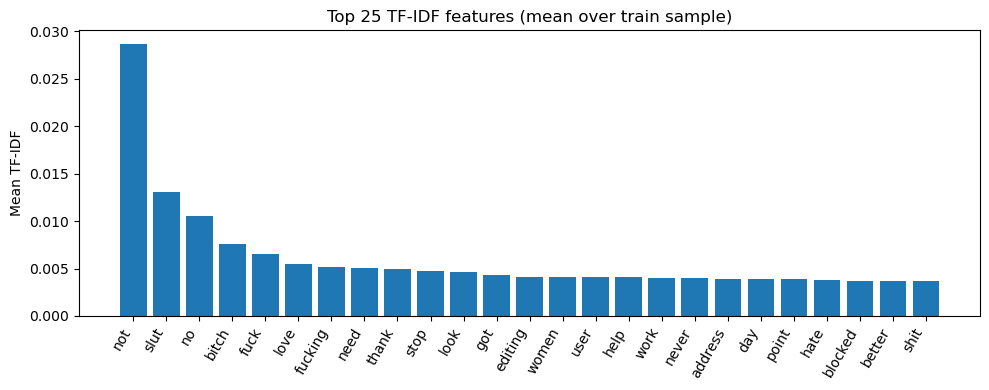

[('not', np.float64(0.028654678445272374)),
 ('slut', np.float64(0.013018223684821048)),
 ('no', np.float64(0.010518538552529383)),
 ('bitch', np.float64(0.0075301246055009844)),
 ('fuck', np.float64(0.0065537036580617155)),
 ('love', np.float64(0.0054864209172531125)),
 ('fucking', np.float64(0.005180345239945899)),
 ('need', np.float64(0.005006765465394992)),
 ('thank', np.float64(0.004906618801580424)),
 ('stop', np.float64(0.0047631465354524664))]

In [50]:
# Cell R5 — TF-IDF feature inspection (top weighted features)
# We inspect features from the trained TF-IDF vectorizer used in the LR baseline.

# Compute average TF-IDF across a sample of training docs and show top features
X_train_sample = X_train
max_docs = 50_000
if X_train.shape[0] > max_docs:
    rng = np.random.default_rng(SEED)
    idx = rng.choice(X_train.shape[0], size=max_docs, replace=False)
    X_train_sample = X_train[idx]

mean_tfidf = np.asarray(X_train_sample.mean(axis=0)).ravel()
feature_names = np.array(vectorizer.get_feature_names_out())

top_k = 25
top_idx = mean_tfidf.argsort()[-top_k:][::-1]
top_feats = feature_names[top_idx]
top_vals = mean_tfidf[top_idx]

plt.figure(figsize=(10, 4))
plt.bar(top_feats, top_vals)
plt.title(f"Top {top_k} TF-IDF features (mean over train sample)")
plt.ylabel("Mean TF-IDF")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

list(zip(top_feats[:10], top_vals[:10]))


## Cell R5 — What this does
- Adds another interpretation visualization by showing **high-weight TF-IDF n-grams**.
- Useful in the report to explain what the TF-IDF model is “paying attention to.”
- Uses sampling to reduce memory/time cost.


# Embedding-specific adaptation notes (write this into your report)

Even though the **cleaning** is shared, each embedding has a **feature-building adaptation**:

### TF-IDF
- Input: cleaned `text`
- Fit vectorizer on **train only** to prevent leakage.
- Uses **1–2 grams** to capture short phrases typical in toxic/hate speech.

### Word2Vec (Skip-gram / CBOW)
- Input: tokenized cleaned text: `tokens = text.split()`
- Train Word2Vec on **train tokens only** to prevent leakage.
- Map tokens to indices; initialize GRU embedding layer from Word2Vec vectors.
- Use `<UNK>` for OOV words and `<PAD>` for padding.

### Why Logistic Regression for TF-IDF (Version A)
- TF-IDF produces a sparse bag-of-words vector where token order is not represented.
- Logistic Regression is a standard linear baseline that pairs well with sparse TF-IDF features.


In [51]:
# Cell R6 — Experiment Table 1: TF-IDF + LR hyperparameter tuning log
# Re-run quick evaluation on validation to build a table you can paste into your report.

rows = []
for C in C_grid:
    clf = LogisticRegression(C=C, max_iter=2000, class_weight="balanced", n_jobs=-1)
    clf.fit(X_train, y_train)
    val_pred = clf.predict(X_val)
    rows.append({
        "model": "TF-IDF+LR",
        "C": C,
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_macro_f1": f1_score(y_val, val_pred, average="macro"),
        "val_macro_precision": precision_score(y_val, val_pred, average="macro", zero_division=0),
        "val_macro_recall": recall_score(y_val, val_pred, average="macro", zero_division=0),
        "ngram_range": "(1,2)",
        "max_features": 50000,
        "min_df": 2,
        "sublinear_tf": True,
    })

tfidf_tuning_table = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
tfidf_tuning_table.head(10)


,model,C,val_accuracy,val_macro_f1,val_macro_precision,val_macro_recall,ngram_range,max_features,min_df,sublinear_tf
0,TF-IDF+LR,1.0,0.834953,0.765382,0.739613,0.823613,"(1,2)",50000,2,True
1,TF-IDF+LR,3.0,0.835704,0.765079,0.739588,0.820820,"(1,2)",50000,2,True
2,TF-IDF+LR,0.3,0.832427,0.763114,0.737428,0.823255,"(1,2)",50000,2,True
3,TF-IDF+LR,10.0,0.834475,0.762848,0.737706,0.817360,"(1,2)",50000,2,True
4,TF-IDF+LR,0.1,0.826761,0.756698,0.731635,0.818321,"(1,2)",50000,2,True


## Cell R6 — What this does
- Produces **Experiment Table 1** showing TF-IDF + LR tuning results on validation.
- Includes both metrics and key TF-IDF settings so the table is self-contained for the report.


In [52]:
# Cell R7 — Experiment Table 2: GRU configuration + results summary (fill after running)

gru_config = {
    "MAX_LEN": MAX_LEN,
    "emb_dim": 100,
    "hidden_dim": 128,
    "n_layers": 1,
    "dropout": 0.2,
    "batch_size": 256,
    "lr": 1e-3,
    "epochs_max": 5,
    "early_stopping_patience": 2,
    "loss": "BCEWithLogitsLoss(pos_weight)",
    "threshold": 0.5,
}

rows = []
# These dicts exist if you ran the experiments; otherwise they'll be added later.
if "w2v_sg_metrics" in globals():
    rows.append({"model": "W2V Skip-gram + GRU", **gru_config, **w2v_sg_metrics})
if "w2v_cbow_metrics" in globals():
    rows.append({"model": "W2V CBOW + GRU", **gru_config, **w2v_cbow_metrics})

gru_results_table = pd.DataFrame(rows)
gru_results_table


,model,MAX_LEN,emb_dim,hidden_dim,n_layers,dropout,batch_size,lr,epochs_max,early_stopping_patience,loss,threshold,w2v_skipgram_gru_accuracy,w2v_skipgram_gru_macro_f1,w2v_skipgram_gru_macro_precision,w2v_skipgram_gru_macro_recall,w2v_cbow_gru_accuracy,w2v_cbow_gru_macro_f1,w2v_cbow_gru_macro_precision,w2v_cbow_gru_macro_recall
0,W2V Skip-gram + GRU,60,100,128,1,0.2,256,0.001,5,2,BCEWithLogitsLoss(pos_weight),0.5,0.855878,0.786467,0.761221,0.831385,NaN,NaN,NaN,NaN
1,W2V CBOW + GRU,60,100,128,1,0.2,256,0.001,5,2,BCEWithLogitsLoss(pos_weight),0.5,NaN,NaN,NaN,NaN,0.840327,0.776112,0.748609,0.842513


## Cell R7 — What this does
- Produces **Experiment Table 2** summarizing GRU hyperparameters and final test metrics.
- You can paste this table into the report to satisfy the “2+ experiment tables” rubric requirement.


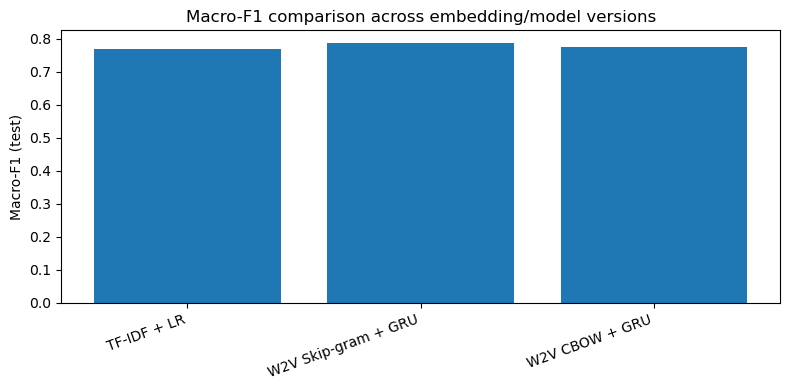

In [53]:
# Cell R8 — Visual comparison: macro-F1 across versions
models = []
macro_f1s = []

# TF-IDF/LR is always available
models.append("TF-IDF + LR")
macro_f1s.append(tfidf_lr_metrics["tfidf_lr_macro_f1"])

if "w2v_sg_metrics" in globals():
    models.append("W2V Skip-gram + GRU")
    macro_f1s.append(w2v_sg_metrics["w2v_skipgram_gru_macro_f1"])

if "w2v_cbow_metrics" in globals():
    models.append("W2V CBOW + GRU")
    macro_f1s.append(w2v_cbow_metrics["w2v_cbow_gru_macro_f1"])

plt.figure(figsize=(8,4))
plt.bar(models, macro_f1s)
plt.title("Macro-F1 comparison across embedding/model versions")
plt.ylabel("Macro-F1 (test)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## Cell R8 — What this does
- Adds a **visual comparison** (bar chart) for macro-F1 across all versions.
- This supports the “Results & Comparative Discussion” rubric item requiring visual comparisons.


# Contribution statement template (copy into your final report)

**Shared team components**
- Dataset selection and justification: (names)
- Shared preprocessing + split protocol: (names)
- Shared evaluation metrics and reporting format: (names)

**Individual contributions**
- Member A (Traditional ML): TF-IDF + Logistic Regression experiments, hyperparameter tuning, analysis.
- Member B (RNN/LSTM/GRU): model architecture, training regime, embedding integration.
- Member C (...): ...
- Member D (...): ...

**Reproducibility**
- Random seed: 42
- Stratified 80/10/10 split with fixed seed
- Feature building on train only (TF-IDF fit / Word2Vec training) to avoid leakage.


In [54]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop = set(ENGLISH_STOP_WORDS) - {"no","not","nor","never"}

counter = Counter()
for t in texts:
    counter.update([w for w in t.split() if w not in stop])

top_items = counter.most_common(25)


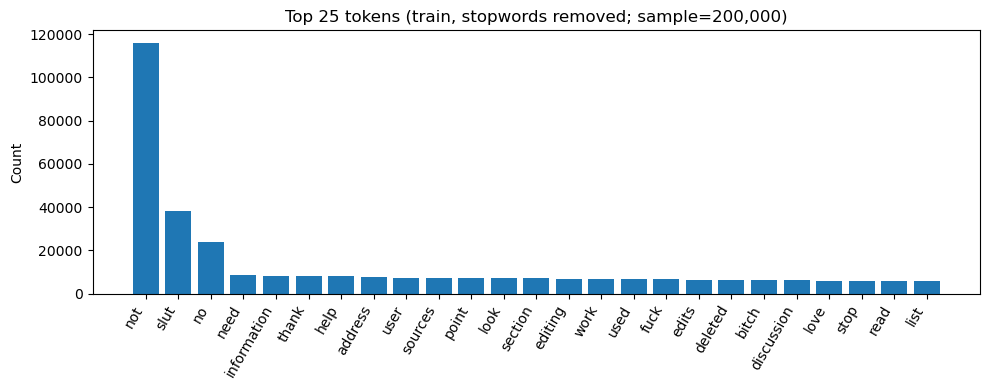

[('not', 115944),
 ('slut', 37997),
 ('no', 23701),
 ('need', 8766),
 ('information', 8062),
 ('thank', 8006),
 ('help', 7990),
 ('address', 7923),
 ('user', 7438),
 ('sources', 7407)]

In [55]:
# Option A — Top tokens after removing stopwords (for visualization only)

from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Keep negations (important for meaning)
stop = set(ENGLISH_STOP_WORDS) - {"no", "not", "nor", "never"}

# Use a sample for speed if your train set is huge
texts = train_df["text"]
SAMPLE_N = 200_000  # set None to use all train
if SAMPLE_N is not None and SAMPLE_N < len(texts):
    texts = texts.sample(SAMPLE_N, random_state=SEED)

counter = Counter()
for t in texts:
    counter.update([w for w in t.split() if w not in stop])

top_k = 25
top_items = counter.most_common(top_k)

words = [w for w, c in top_items]
counts = [c for w, c in top_items]

plt.figure(figsize=(10, 4))
plt.bar(words, counts)
plt.title(f"Top {top_k} tokens (train, stopwords removed; sample={len(texts):,})")
plt.ylabel("Count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

top_items[:10]


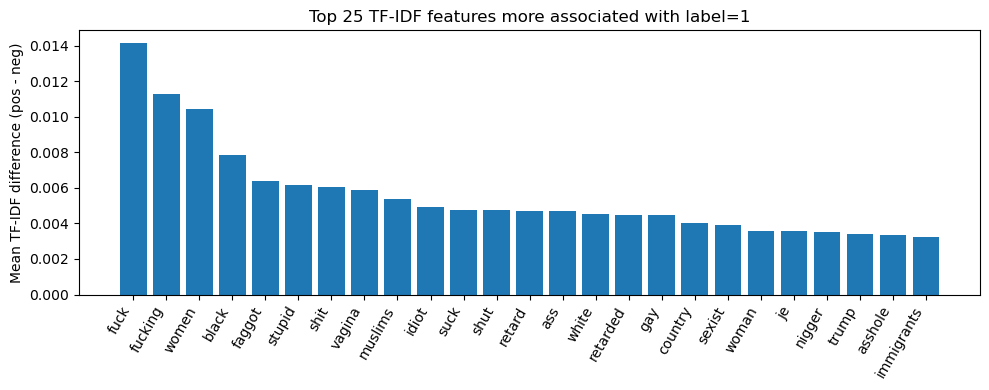

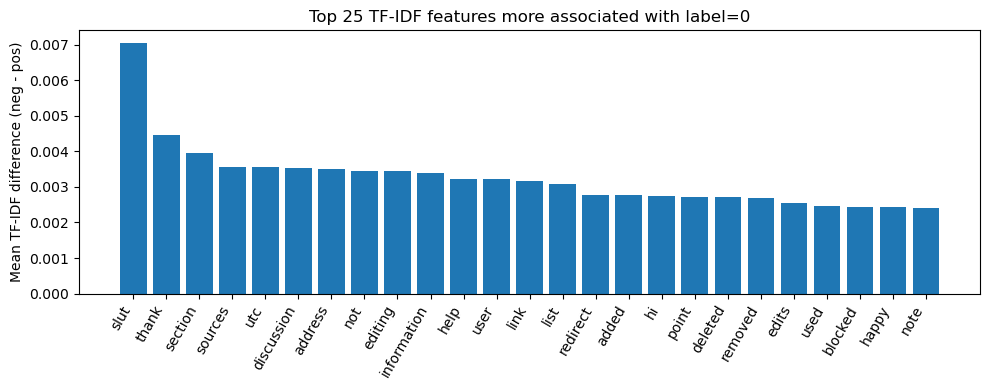

[('fuck', np.float64(0.014148968278370094)),
 ('fucking', np.float64(0.011253478102688046)),
 ('women', np.float64(0.01044094108994881)),
 ('black', np.float64(0.007853112429650774)),
 ('faggot', np.float64(0.006412230968455557)),
 ('stupid', np.float64(0.006140156943077901)),
 ('shit', np.float64(0.006049986209235919)),
 ('vagina', np.float64(0.005885520845683778)),
 ('muslims', np.float64(0.005385407415937672)),
 ('idiot', np.float64(0.0049491175343377046))]

In [56]:
# Option B — Class-specific TF-IDF terms (difference of mean TF-IDF by class)

import numpy as np
import matplotlib.pyplot as plt

# Assumes you already created:
# vectorizer, X_train (CSR sparse), y_train (0/1)
feature_names = np.array(vectorizer.get_feature_names_out())

X_pos = X_train[y_train == 1]
X_neg = X_train[y_train == 0]

# Mean TF-IDF per feature for each class
mean_pos = np.asarray(X_pos.mean(axis=0)).ravel()
mean_neg = np.asarray(X_neg.mean(axis=0)).ravel()

# Difference scores
diff_pos = mean_pos - mean_neg   # high => more associated with positive class
diff_neg = mean_neg - mean_pos   # high => more associated with negative class

top_k = 25

# Top features for positive class
top_pos_idx = diff_pos.argsort()[-top_k:][::-1]
top_pos_terms = feature_names[top_pos_idx]
top_pos_scores = diff_pos[top_pos_idx]

plt.figure(figsize=(10, 4))
plt.bar(top_pos_terms, top_pos_scores)
plt.title(f"Top {top_k} TF-IDF features more associated with label=1")
plt.ylabel("Mean TF-IDF difference (pos - neg)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Top features for negative class
top_neg_idx = diff_neg.argsort()[-top_k:][::-1]
top_neg_terms = feature_names[top_neg_idx]
top_neg_scores = diff_neg[top_neg_idx]

plt.figure(figsize=(10, 4))
plt.bar(top_neg_terms, top_neg_scores)
plt.title(f"Top {top_k} TF-IDF features more associated with label=0")
plt.ylabel("Mean TF-IDF difference (neg - pos)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

list(zip(top_pos_terms[:10], top_pos_scores[:10]))
